In [8]:
import pandas as pd 
import gzip
import matplotlib.pyplot as plt


# ClinVar UTR Variant Data

The VCF file was manually downloaded from the following link: [ClinVar GRCh38 VCF](https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz).

After downloading, variants located in the untranslated regions (UTRs) – including both 3' UTR and 5' UTR variants – were filtered. The filtered data was then written into a CSV file for further analysis.



In [16]:
vcf_file = "clinvar.vcf.gz" 

# annotation keys to extract from the INFO field
measurement_keys = [
    "AF_ESP", "AF_EXAC", "AF_TGP", "ALLELEID", "CLNDISDB", "CLNDN",
    "CLNHGVS", "CLNREVSTAT", "CLNSIG", "CLNVC", "CLNVCSO", "GENEINFO",
    "MC", "ORIGIN", "RS"
]

def parse_info(info_str):
    info = {}
    for item in info_str.split(";"):
        if "=" in item:
            key, value = item.split("=", 1)
            info[key] = value
        else:
            info[item] = True
    return info

records = []
with gzip.open(vcf_file, "rt") as f:
    for line in f:
        line = line.strip()

        if line.startswith("##"):
            continue
    
        if line.startswith("#CHROM"):
            headers = line.lstrip("#").split("\t")
            continue
 
        parts = line.split("\t")
        if len(parts) < len(headers):
            continue
        record = dict(zip(headers, parts))

        if "UTR" in record["INFO"]:
            info_dict = parse_info(record["INFO"])

            for key in measurement_keys:
                record[key] = info_dict.get(key, None)

            if "MC" in info_dict:
                parts_mc = info_dict["MC"].split("|")
                if len(parts_mc) > 1:
                    record["Effect"] = parts_mc[1]
                else:
                    record["Effect"] = info_dict["MC"]
            else:
                record["Effect"] = None
            records.append(record)

if records:
    df = pd.DataFrame(records)

    columns_to_display = ["CHROM", "POS", "ID", "REF", "ALT", "Effect"] + measurement_keys
    table = df[columns_to_display]
    output_csv = "Clinvar_UTR_Variant_Table.csv"
    table.to_csv(output_csv, index=False)
    print(f"UTR Variant Table has been saved to '{output_csv}'")


UTR Variant Table has been saved to 'Clinvar_UTR_Variant_Table.csv'


### Key Definitions:

- **AF_ESP**: Allele Frequency in the ESP (Exome Sequencing Project) population.
- **AF_EXAC**: Allele Frequency in the EXAC (Exome Aggregation Consortium) population.
- **AF_TGP**: Allele Frequency in the TGP (The 1000 Genomes Project) population.
- **ALLELEID**: Unique identifier for the allele.
- **CLNDISDB**: The disease database(s) that the variant is associated with.
- **CLNDN**: Clinical diagnosis associated with the variant (e.g., disease name).
- **CLNHGVS**: The HGVS (Human Genome Variation Society) nomenclature of the variant, representing the change in nucleotide sequence.
- **CLNREVSTAT**: Review status of the clinical interpretation of the variant (e.g., how the variant's pathogenicity has been reviewed).
- **CLNSIG**: Clinical significance of the variant (e.g., benign, pathogenic, likely pathogenic).
- **CLNVC**: Variant classification (e.g., single nucleotide variant).
- **CLNVCSO**: Sequence ontology for the variant (a standardized description of the type of variation).
- **GENEINFO**: Gene associated with the variant (Gene Symbol and Gene ID).
- **MC**: Mutation classification, often indicating the molecular mechanism or impact of the variant.
- **ORIGIN**: The origin of the variant (e.g., germline or somatic).
- **RS**: dbSNP (database of single nucleotide polymorphisms) reference ID.


# Data summary

In [19]:
# Load the CSV file
data_path ='~/VEP_DNA/data/UTR/Clinvar_UTR_Variant_Table.csv'  
data_df = pd.read_csv(data_path)

print("Data Summary:")
data_df.info()
data_df.head()


Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221961 entries, 0 to 221960
Data columns (total 21 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   CHROM       221961 non-null  object 
 1   POS         221961 non-null  int64  
 2   ID          221961 non-null  int64  
 3   REF         221961 non-null  object 
 4   ALT         221961 non-null  object 
 5   Effect      221961 non-null  object 
 6   AF_ESP      12441 non-null   float64
 7   AF_EXAC     26026 non-null   float64
 8   AF_TGP      40273 non-null   float64
 9   ALLELEID    221961 non-null  int64  
 10  CLNDISDB    221880 non-null  object 
 11  CLNDN       221880 non-null  object 
 12  CLNHGVS     221957 non-null  object 
 13  CLNREVSTAT  221907 non-null  object 
 14  CLNSIG      221907 non-null  object 
 15  CLNVC       221961 non-null  object 
 16  CLNVCSO     221961 non-null  object 
 17  GENEINFO    221961 non-null  object 
 18  MC          221961 non-null  o

/scratch/local/63254297/ipykernel_470181/2132722529.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data_df = pd.read_csv(data_path)


,CHROM,POS,ID,REF,ALT,Effect,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,...,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS
0,1,981131,3234236,C,T,"5_prime_UTR_variant,SO:0001627",NaN,NaN,NaN,3393359,...,not_provided,NC_000001.11:g.981131C>T,"criteria_provided,_single_submitter",Likely_benign,single_nucleotide_variant,SO:0001483,PERM1:84808,"SO:0001623|5_prime_UTR_variant,SO:0001627|intr...",1.0,NaN
1,1,1013541,1185394,T,C,5_prime_UTR_variant,0.88579,NaN,0.90315,1175251,...,Mendelian_susceptibility_to_mycobacterial_dise...,NC_000001.11:g.1013541T>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,ISG15:9636,SO:0001623|5_prime_UTR_variant,1.0,15842.0
2,1,1013549,3040451,GGCCCACAGCCCACA,G,5_prime_UTR_variant,NaN,NaN,NaN,3213980,...,ISG15-related_disorder,NC_000001.11:g.1013553CACAGCC[1],no_assertion_criteria_provided,Likely_benign,Microsatellite,SO:0000289,ISG15:9636,SO:0001623|5_prime_UTR_variant,1.0,NaN
3,1,1014482,3050573,C,A,3_prime_UTR_variant,NaN,NaN,NaN,3216732,...,ISG15-related_disorder,NC_000001.11:g.1014482C>A,no_assertion_criteria_provided,Likely_benign,single_nucleotide_variant,SO:0001483,ISG15:9636,SO:0001624|3_prime_UTR_variant,1.0,NaN
4,1,1055000,263157,C,T,3_prime_UTR_variant,0.34176,0.33342,0.34345,249353,...,not_provided|not_specified|Congenital_myasthen...,NC_000001.11:g.1055000C>T,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,AGRN:375790,SO:0001624|3_prime_UTR_variant,1.0,3121561.0


# Summary of Clinical Significance

Clinical Significance Counts:
CLNSIG
Uncertain_significance                                      126083
Likely_benign                                                45328
Benign                                                       21019
Pathogenic                                                    9600
Conflicting_classifications_of_pathogenicity                  8298
Benign/Likely_benign                                          4635
Likely_pathogenic                                             3809
Pathogenic/Likely_pathogenic                                  1798
not_provided                                                   735
drug_response                                                  445
no_classification_for_the_single_variant                        27
association                                                     23
risk_factor                                                     23
other                                                           17
Affects                  

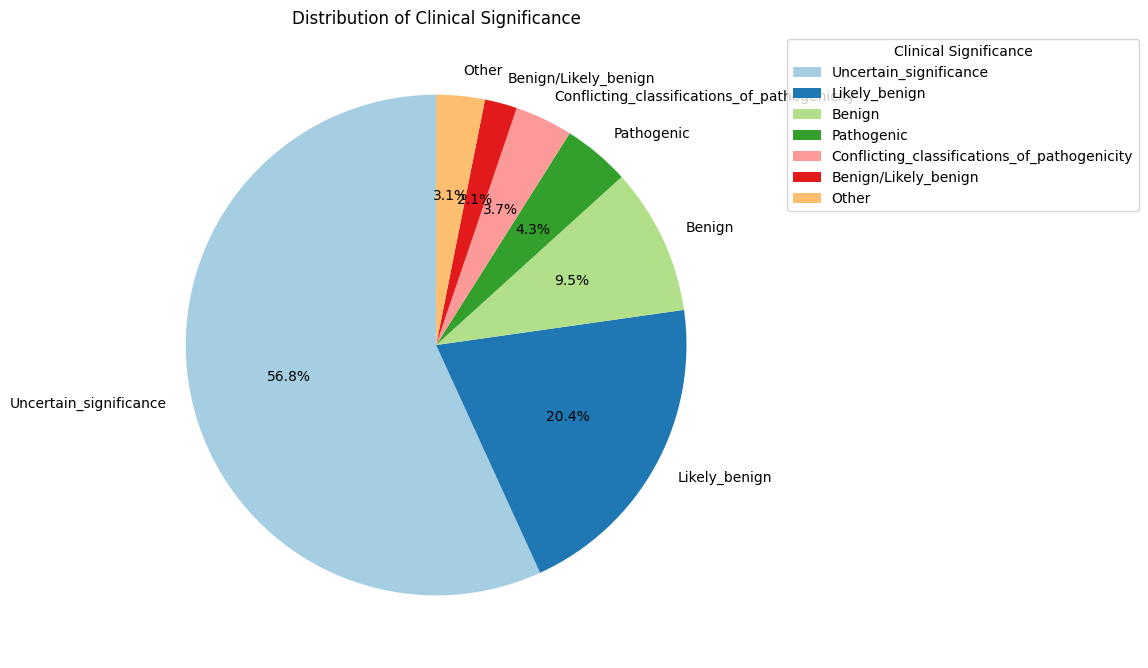

In [20]:
# count the occurrences of each clinical significance value
clnsig_counts = data_df['CLNSIG'].value_counts()

print("Clinical Significance Counts:")
print(clnsig_counts)

# select the top N categories and combine the rest into 'Other'
top_n = 6
top_categories = clnsig_counts.head(top_n)
other_categories = clnsig_counts.tail(len(clnsig_counts) - top_n).sum()
clnsig_counts_filtered = pd.concat([top_categories, pd.Series({'Other': other_categories})])

plt.figure(figsize=(10, 8)) 
ax = clnsig_counts_filtered.plot(kind='pie', autopct='%1.1f%%', startangle=90, legend=False, colors=plt.cm.Paired.colors)
plt.title('Distribution of Clinical Significance')
plt.ylabel('')  
plt.legend(clnsig_counts_filtered.index, title="Clinical Significance", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Effect of Variants

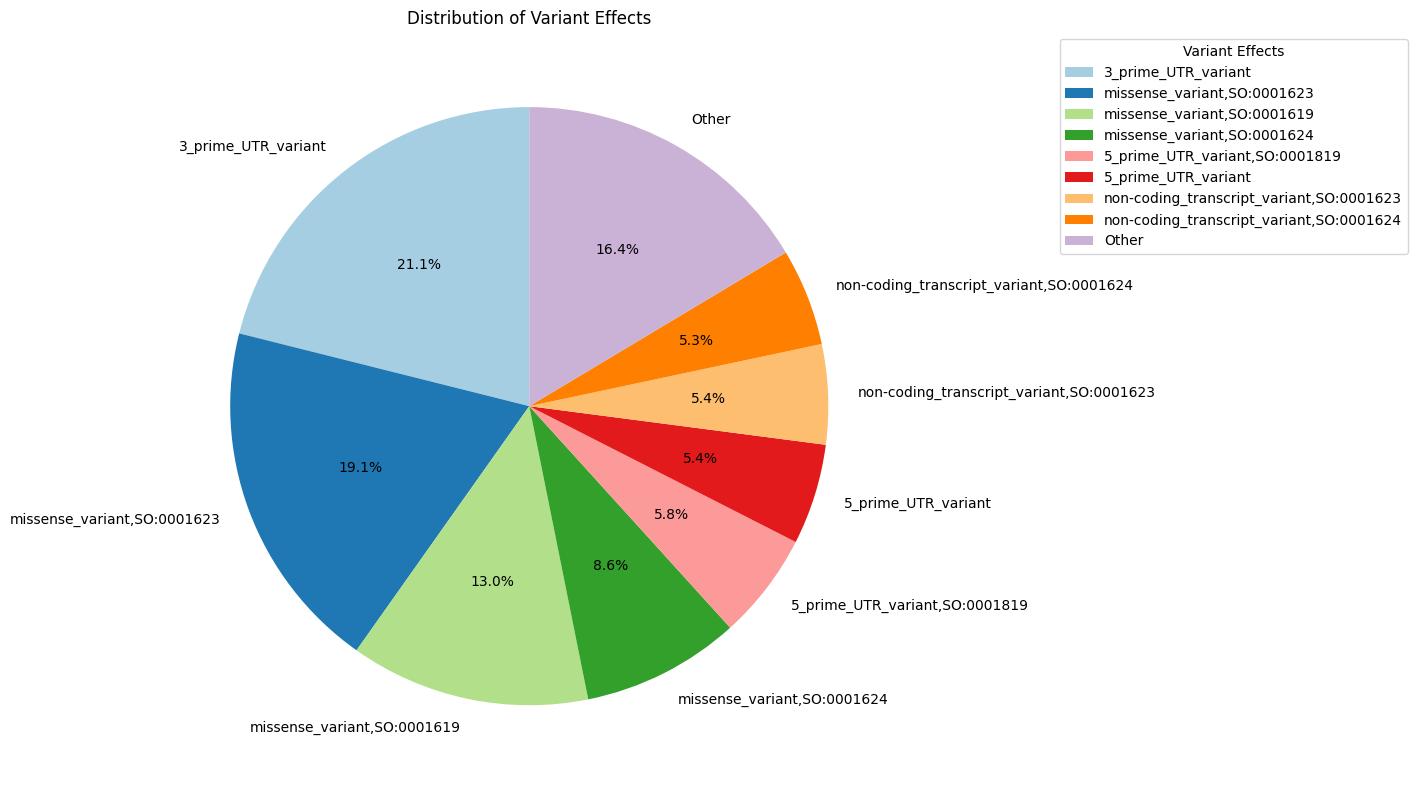

In [21]:
# count the occurrences of each variant effect
effect_counts = data_df['Effect'].value_counts()
top_n = 8
top_effects = effect_counts.head(top_n)
other_effects = effect_counts.tail(len(effect_counts) - top_n).sum()
effect_counts_filtered = pd.concat([top_effects, pd.Series({'Other': other_effects})])

plt.figure(figsize=(12, 8))  
ax = effect_counts_filtered.plot(kind='pie', autopct='%1.1f%%', startangle=90, legend=False, colors=plt.cm.Paired.colors)

plt.title('Distribution of Variant Effects')
plt.ylabel('')  

plt.legend(effect_counts_filtered.index, title="Variant Effects", bbox_to_anchor=(1.2, 1), loc='upper left')


plt.tight_layout()
plt.show()


# Distribution of Allele Frequencies

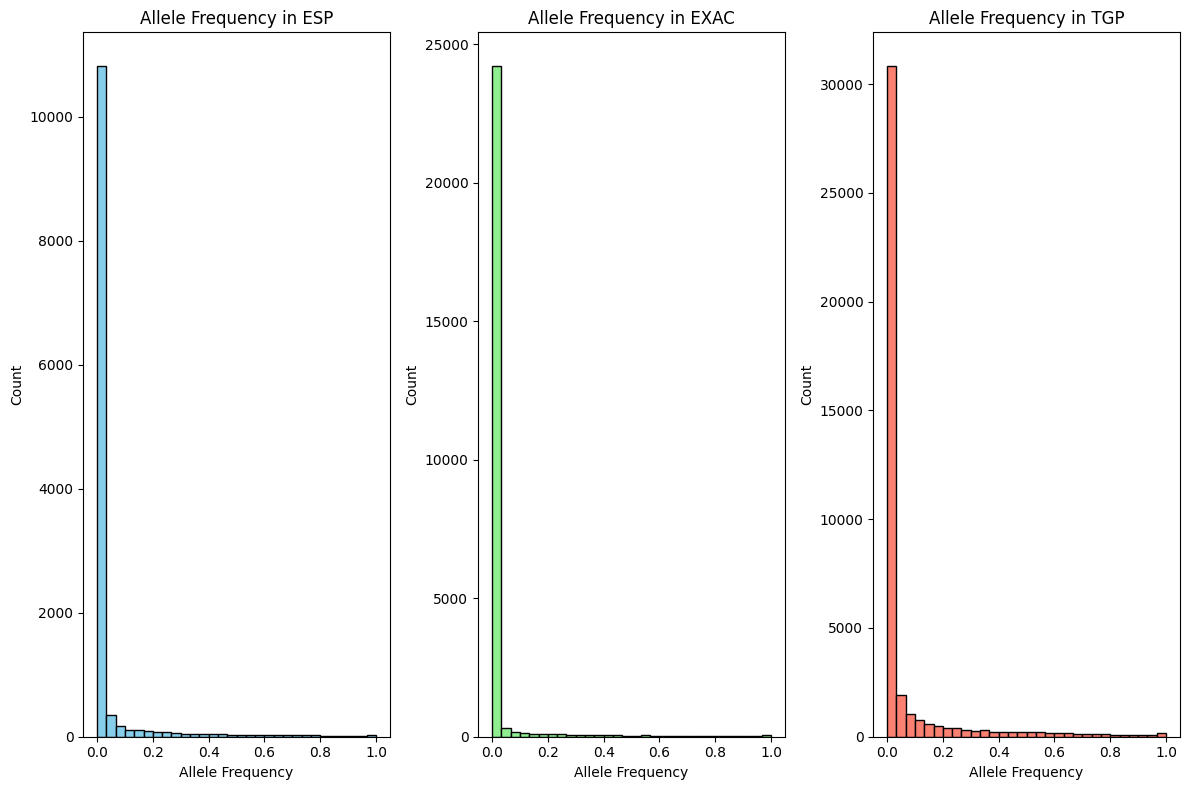

In [22]:
# histograms of allele frequencies
plt.figure(figsize=(12, 8))

# Plot allele frequencies for ESP, EXAC, TGP
plt.subplot(1, 3, 1)
plt.hist(data_df['AF_ESP'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Allele Frequency in ESP')
plt.xlabel('Allele Frequency')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
plt.hist(data_df['AF_EXAC'].dropna(), bins=30, color='lightgreen', edgecolor='black')
plt.title('Allele Frequency in EXAC')
plt.xlabel('Allele Frequency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
plt.hist(data_df['AF_TGP'].dropna(), bins=30, color='salmon', edgecolor='black')
plt.title('Allele Frequency in TGP')
plt.xlabel('Allele Frequency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


# Clinical Significance by Variant Effect

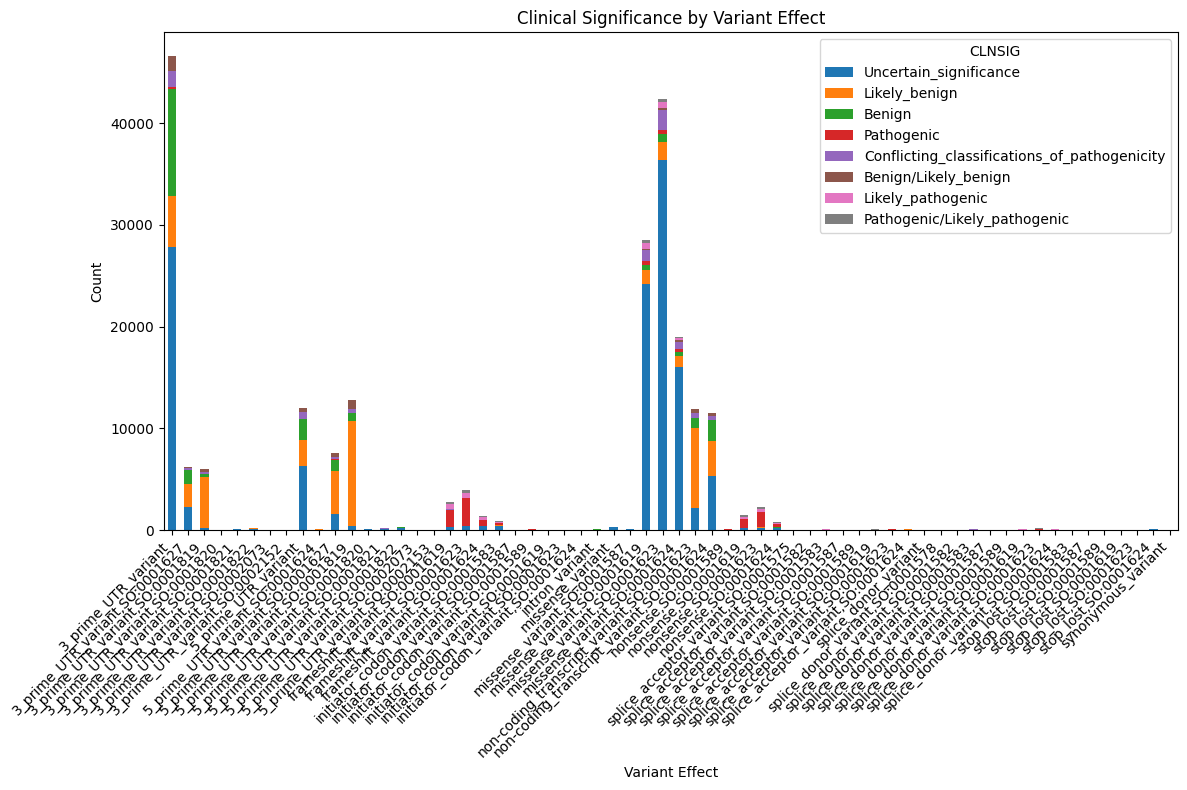

In [23]:
# group by Effect and CLNSIG, and count the occurrences
effect_clnsig_counts = data_df.groupby(['Effect', 'CLNSIG']).size().unstack().fillna(0)

top_8_clnsig = effect_clnsig_counts.sum(axis=0).nlargest(8).index

effect_clnsig_counts_top_8 = effect_clnsig_counts[top_8_clnsig]

# plot the stacked bar chart
effect_clnsig_counts_top_8.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Clinical Significance by Variant Effect')
plt.xlabel('Variant Effect')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Gene Distribution

Top 10 Genes with the Most Variants:
GENEINFO
CDH1:999       2664
MLH1:4292      2000
APC:324        1989
MSH6:2956      1920
PMS2:5395      1674
SCN1A:6323     1508
PTEN:5728      1497
CHEK2:11200    1336
BRCA1:672      1222
PRX:57716      1207
Name: count, dtype: int64


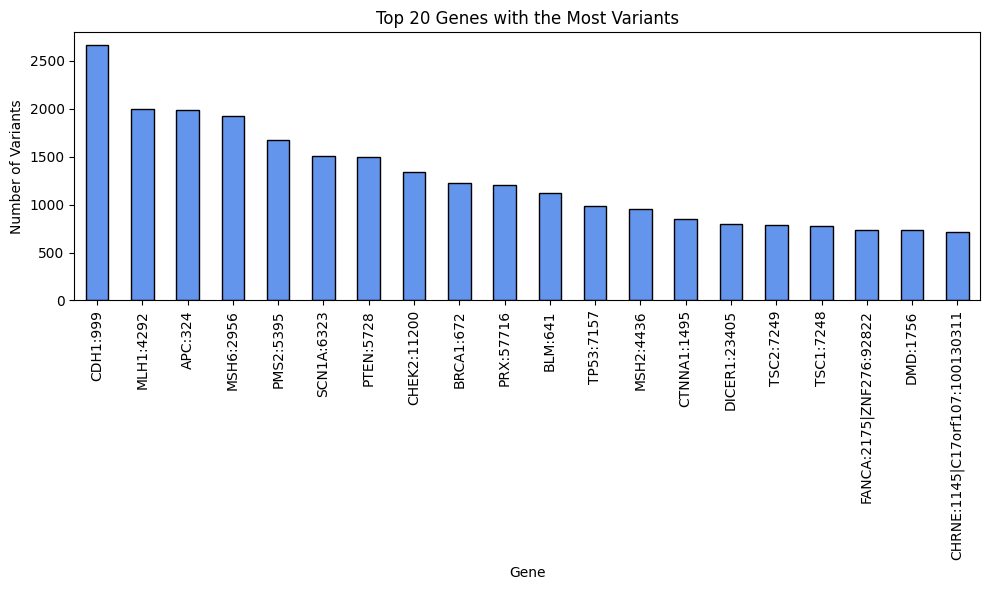

In [24]:
# count the number of variants associated with each gene
gene_counts = data_df['GENEINFO'].value_counts()


print("Top 10 Genes with the Most Variants:")
print(gene_counts.head(10))

# plot the distribution of variants per gene 
plt.figure(figsize=(10, 6))
gene_counts.head(20).plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title('Top 20 Genes with the Most Variants')
plt.xlabel('Gene')
plt.ylabel('Number of Variants')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
